# Wine Color

<a target="_blank" href="https://colab.research.google.com/github/LuisAngelMendozaVelasco/luisangelmendozavelasco.github.io/blob/master/_portfolio/IBM_Introduction_to_Machine_Learning_Specialization/portfolio-3.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png">Run in Google Colab</a>

**Objective**: Train a Support Vector Machine (SVM) classifier to predict the color of wine based on its chemical properties.

## Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.calibration import LabelEncoder
from sklearn.model_selection import GridSearchCV

sns.set_style("whitegrid")

## Load the dataset

In [2]:
file_url = "https://raw.githubusercontent.com/LuisAngelMendozaVelasco/IBM_Introduction_to_Machine_Learning_Specialization/refs/heads/main/Supervised_Machine_Learning-Classification/Week2/Labs/data/Wine_Quality_Data.csv"
df = pd.read_csv(file_url)
df.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,color
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


## Understand the dataset

We will be using the [wine quality dataset](https://archive.ics.uci.edu/dataset/186/wine+quality). This data set contains various chemical properties of wine, such as acidity, sugar, pH, and alcohol. It also contains a quality metric (3-9, with highest being better) and a color (red or white). 

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         6497 non-null   float64
 1   volatile_acidity      6497 non-null   float64
 2   citric_acid           6497 non-null   float64
 3   residual_sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free_sulfur_dioxide   6497 non-null   float64
 6   total_sulfur_dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  color                 6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


## Visualize the dataset

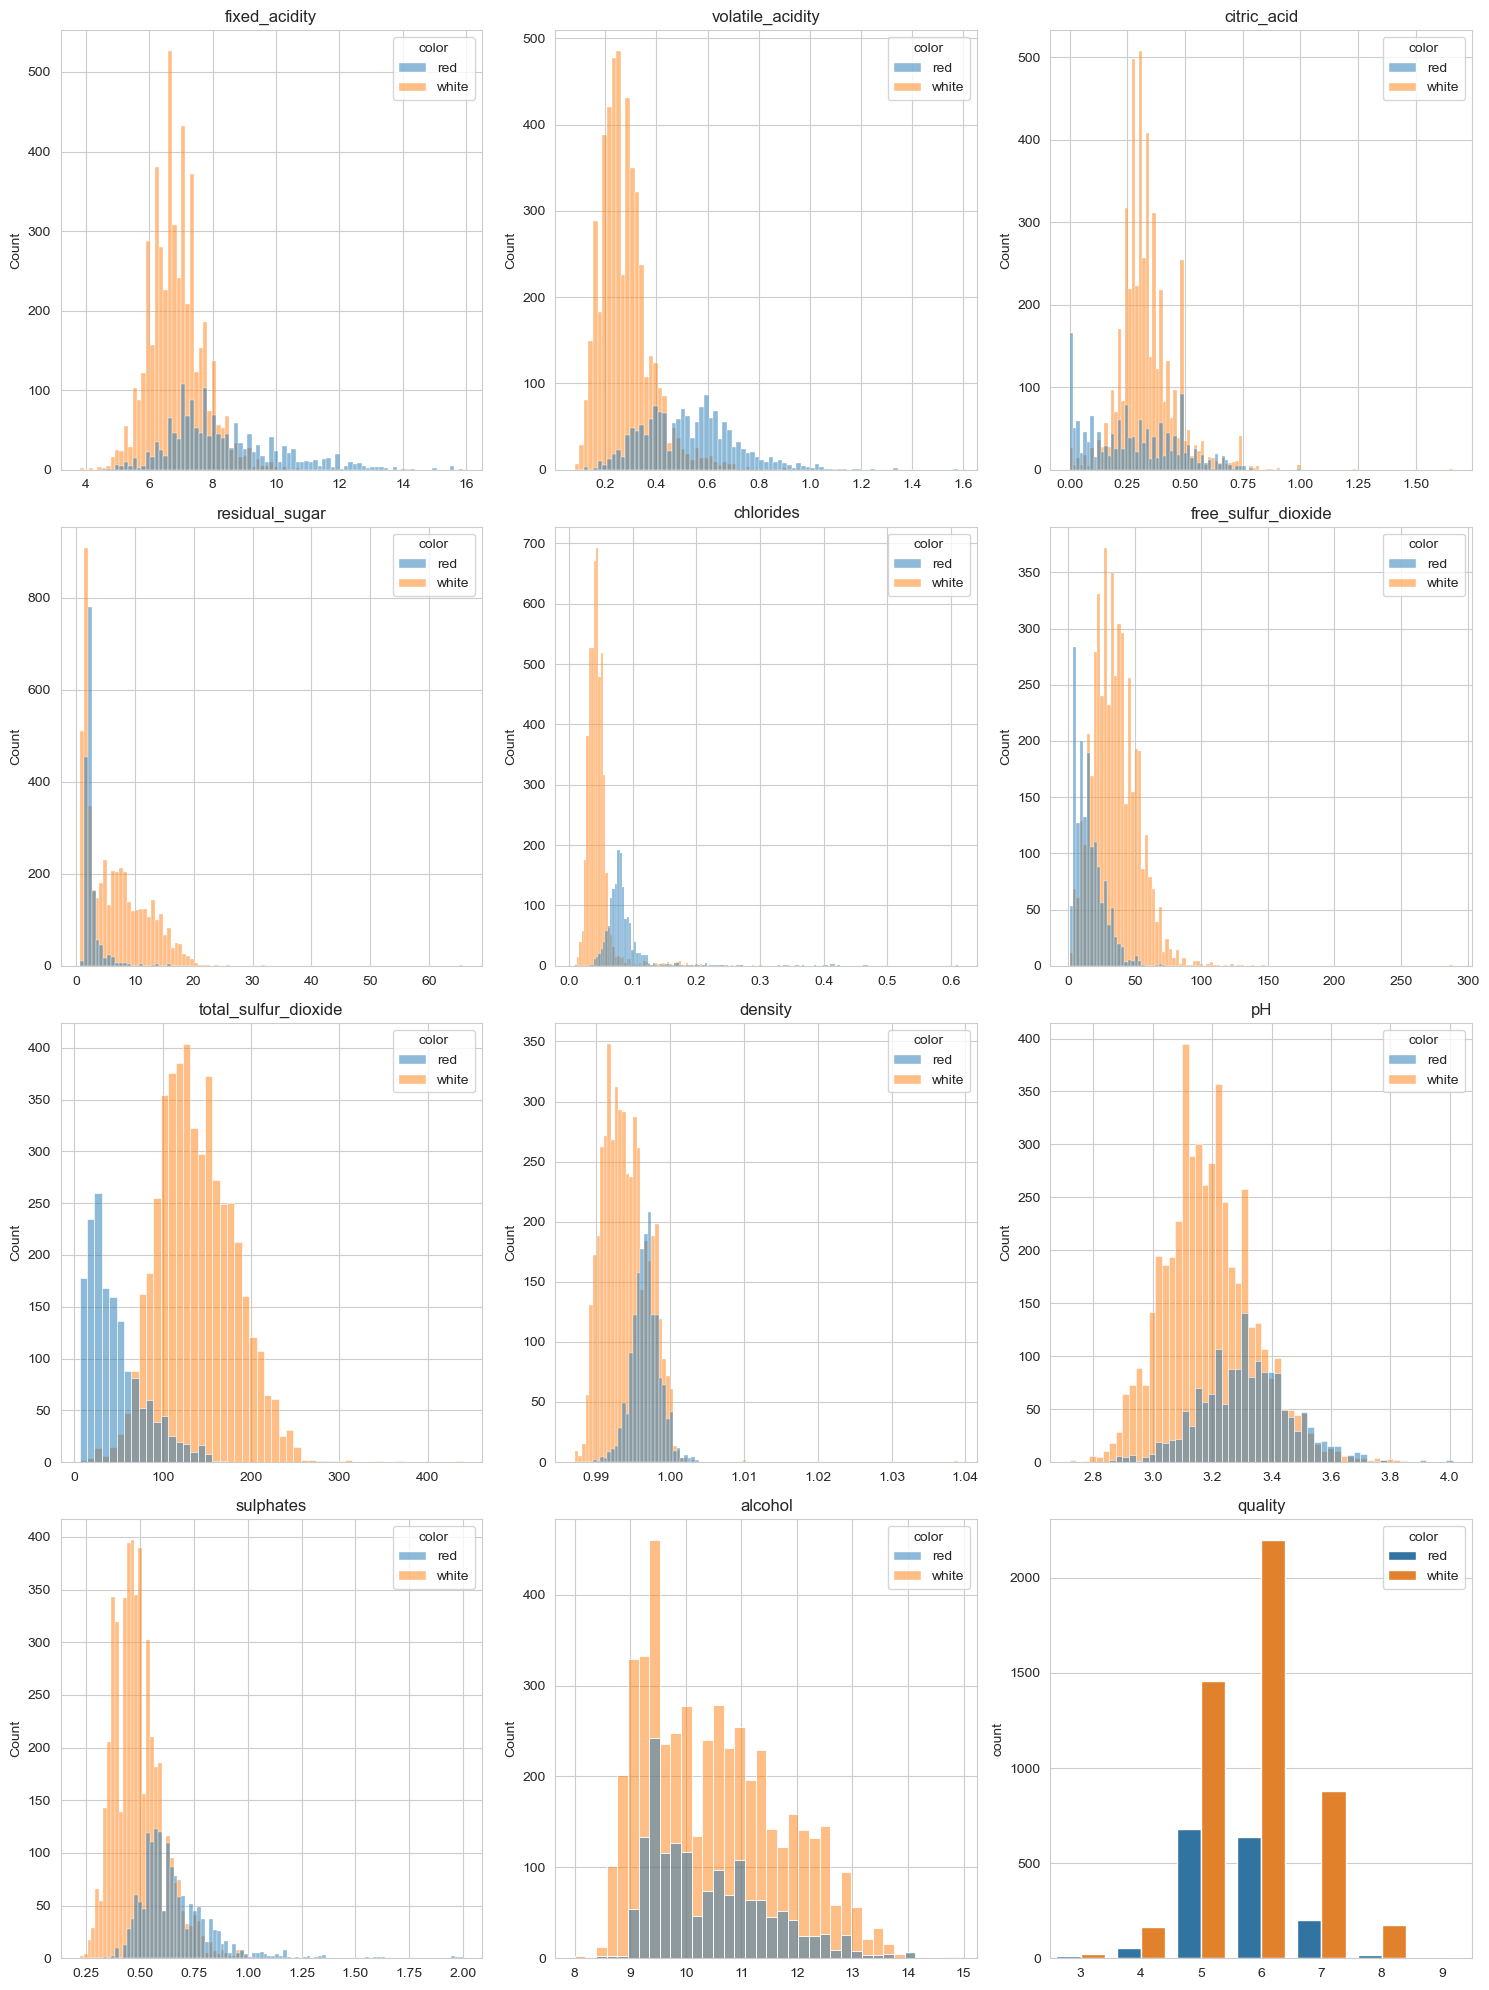

In [4]:
number_features = df.shape[1] - 1
grid_rows = int(np.ceil(number_features / 3))
fig, axs = plt.subplots(grid_rows, 3, figsize=(15, 5 * grid_rows))

for ax, feature in zip(axs.flatten(), df.columns[:-1]):
    if len(df[feature].unique()) <= 10:
        sns.countplot(data=df, x=feature, ax=ax, hue="color")
        ax.set_xlabel("")
        ax.set_title(feature)
    else:
        sns.histplot(data=df, x=feature, ax=ax, hue="color")
        ax.set_xlabel("")
        ax.set_title(feature)

for ax in axs.flatten()[number_features:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## Visualize the class distribution

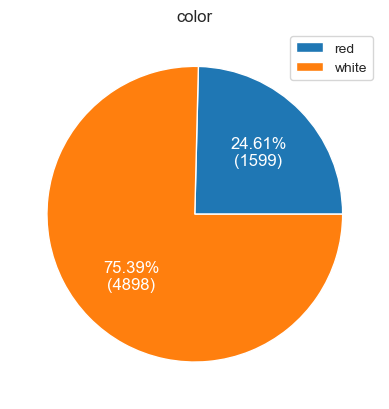

In [5]:
target_feature = "color"
labels, sizes = np.unique(df[target_feature], return_counts=True)

fig, ax = plt.subplots()
ax.pie(sizes, textprops={'color': "w", 'fontsize': '12'}, autopct=lambda pct: "{:.2f}%\n({:d})".format(pct, round(pct/100 * sum(sizes))))
ax.legend([i for i in labels])
ax.set_title(target_feature)
plt.show()

## Preprocess the dataset

In [6]:
le = LabelEncoder()
df[target_feature] = le.fit_transform(df[target_feature])
df.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,color
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0


## Split the dataset into train and test subsets

In [7]:
X = df.drop(columns=[target_feature])
y = df[target_feature]
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (4872, 12)
X_test shape: (1625, 12)


## Train a SVM classifier

In [ ]:
C = [10**i for i in range(6)]
parameters = {'C': C}

svm_classifier = SVC()
clf = GridSearchCV(svm_classifier, parameters, scoring='recall')
clf.fit(X_train, y_train)

,estimator,SVC()
,param_grid,"{'C': [1, 10, ...]}"
,scoring,'recall'
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,10000


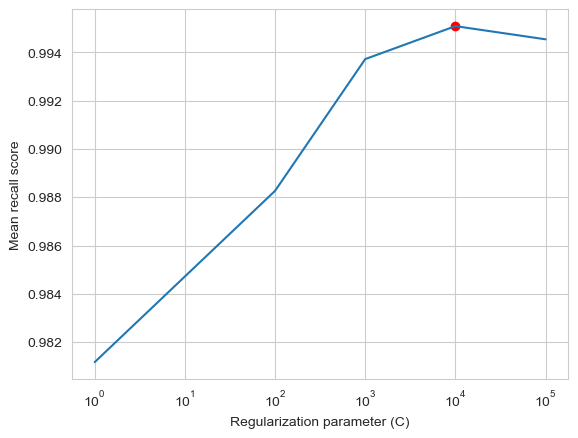

In [9]:
plt.figure()
plt.plot(C, clf.cv_results_['mean_test_score'])
plt.scatter(clf.best_params_['C'], clf.best_score_, color='red')
plt.xlabel("Regularization parameter (C)")
plt.ylabel("Mean recall score")
plt.xscale('log')
plt.show()

## Evaluate the SVM classifier

              precision    recall  f1-score   support

           0     0.9747    0.9847    0.9797       392
           1     0.9951    0.9919    0.9935      1233

    accuracy                         0.9902      1625
   macro avg     0.9849    0.9883    0.9866      1625
weighted avg     0.9902    0.9902    0.9902      1625



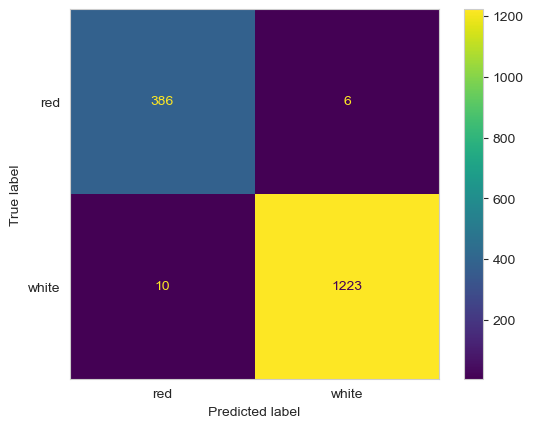

In [10]:
y_pred = clf.best_estimator_.predict(X_test)
print(classification_report(y_test, y_pred, digits=4))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=le.classes_)
plt.grid(False)
plt.show()